In [39]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


In [40]:
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")["y_train"]
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")["y_test"]

In [41]:
import numpy as np
import pandas as pd

# Check for infinity values in X_train
print("Checking for infinity values in X_train...")

# Method 1: Check which rows contain infinity values
inf_mask = np.isinf(X_train).any(axis=1)
invalid_rows = X_train[inf_mask]

print(f"Number of rows with infinity values: {inf_mask.sum()}")
print(f"Total rows in X_train: {len(X_train)}")
print(f"Percentage of rows with infinity: {inf_mask.sum() / len(X_train) * 100:.2f}%")

if len(invalid_rows) > 0:
    print("\nRows with infinity values:")
    print(invalid_rows)
    
    # Show which columns contain infinity values
    inf_columns = X_train.columns[np.isinf(X_train).any(axis=0)]
    print(f"\nColumns containing infinity values: {list(inf_columns)}")
    
    # Count infinity values per column
    inf_count_per_column = np.isinf(X_train).sum()
    inf_count_per_column = inf_count_per_column[inf_count_per_column > 0]
    print("\nInfinity count per column:")
    for col, count in inf_count_per_column.items():
        print(f"  {col}: {count}")
    
    # Show first few rows with infinity for inspection
    print(f"\nFirst 5 rows with infinity values:")
    print(invalid_rows.head())
    
else:
    print("No infinity values found in X_train.")

# Method 2: Check for both positive and negative infinity separately
pos_inf_mask = np.isposinf(X_train).any(axis=1)
neg_inf_mask = np.isneginf(X_train).any(axis=1)

print(f"\nRows with positive infinity: {pos_inf_mask.sum()}")
print(f"Rows with negative infinity: {neg_inf_mask.sum()}")

Checking for infinity values in X_train...
Number of rows with infinity values: 0
Total rows in X_train: 57264
Percentage of rows with infinity: 0.00%
No infinity values found in X_train.

Rows with positive infinity: 0
Rows with negative infinity: 0


In [42]:

# # Drop columns with infinity values
# X_train = X_train.drop(columns=inf_columns)
# print(f"Columns with infinity values have been dropped. Remaining columns: {X_train.columns}")

In [43]:

# # Drop columns with infinity values
# X_test = X_test.drop(columns=inf_columns)
# print(f"Columns with infinity values have been dropped. Remaining columns: {X_test.columns}")

In [44]:
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
shape_before = X_train.shape[1]
shape_after = X_train_pca.shape[1]
print(f"PCA reduced the number of features from {shape_before} to {shape_after}.")

PCA reduced the number of features from 108 to 16.


In [45]:
linear_model = LinearRegression()

linear_model.fit(X_train_pca, y_train)

y_train_pred = linear_model.predict(X_train_pca)
y_test_pred = linear_model.predict(X_test_pca)


In [46]:

# ===============================
# 2. Ridge Pipeline（标准化 + Ridge）
# ===============================
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(
        alpha=1.0,          # L2 正则强度
        random_state=42
    ))
])

# ===============================
# 3. 训练
# ===============================
ridge_model.fit(X_train, y_train)

# ===============================
# 4. 预测 & 评估
# ===============================
y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.6f}")
print(f"Test  MSE: {test_mse:.6f}")

# ===============================
# 5. 系数查看（Ridge 不会稀疏）
# ===============================
coef = ridge_model.named_steps["ridge"].coef_
coef_df = pd.Series(coef, index=X_train.columns).sort_values(key=np.abs, ascending=False)

print("\nTop coefficients by absolute value:")
print(coef_df.head(20))

Train MSE: 2648.402040
Test  MSE: 3406.492564

Top coefficients by absolute value:
coef_adj_all               218.727223
residual_mean              213.987866
std_all_w7680               26.987564
atr_all_w7680              -26.064949
atr_selected_w1920         -15.694689
atr_selected_w60            -9.961268
atr_all_w1920                9.539086
close_ret_all_w30720        -9.080768
atr_selected_w30             9.031840
std_all_w60                  9.001401
atr_selected_w7680           8.531189
std_all_w120                -7.595036
close_ret_all_w7680          7.399999
atr_selected_w480            7.162548
atr_all_w480                -6.593815
std_all_w30720              -6.557365
close_ret_all_w120           5.823346
close_ret_selected_w120     -5.468298
residual_diff               -4.871792
std_all_w480                 4.067479
dtype: float64


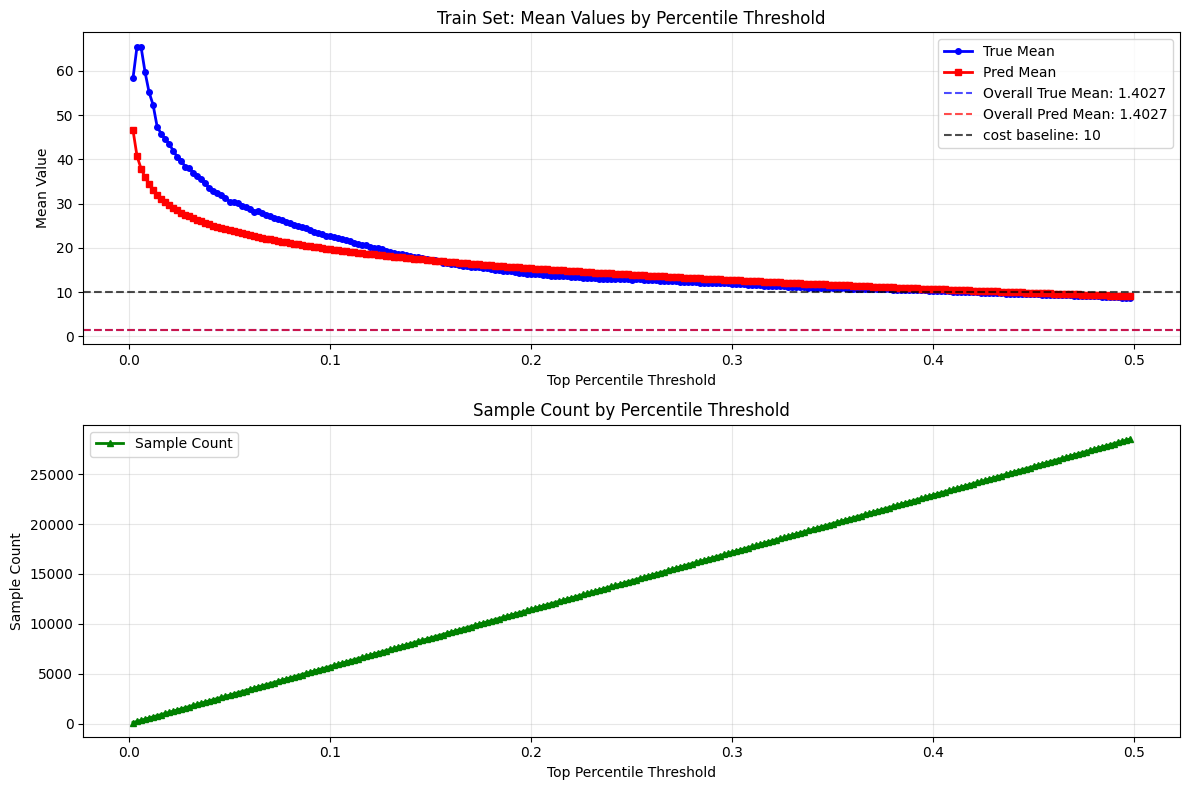

Train Set Evaluation:
  MAE: 35.9114, Relative MAE: 0.6843
  RMSE: 51.5127, Relative RMSE: 0.9815
  R²: 0.0366
  Overall True Mean: 1.4027
  Overall Pred Mean: 1.4027

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    58.3711    46.5724           115   -11.7987
1         0.004    65.5084    40.7240           230   -24.7844
2         0.006    65.4139    37.9055           344   -27.5084
3         0.008    59.6900    35.9312           459   -23.7588
4         0.010    55.1630    34.3703           573   -20.7927
..          ...        ...        ...           ...        ...
244       0.490     8.8254     9.1646         28059     0.3392
245       0.492     8.7891     9.1328         28174     0.3438
246       0.494     8.7307     9.1015         28288     0.3708
247       0.496     8.7086     9.0699         28403     0.3613
248       0.498     8.6780     9.0387         28517     0.3607

[249 rows x 5 columns]


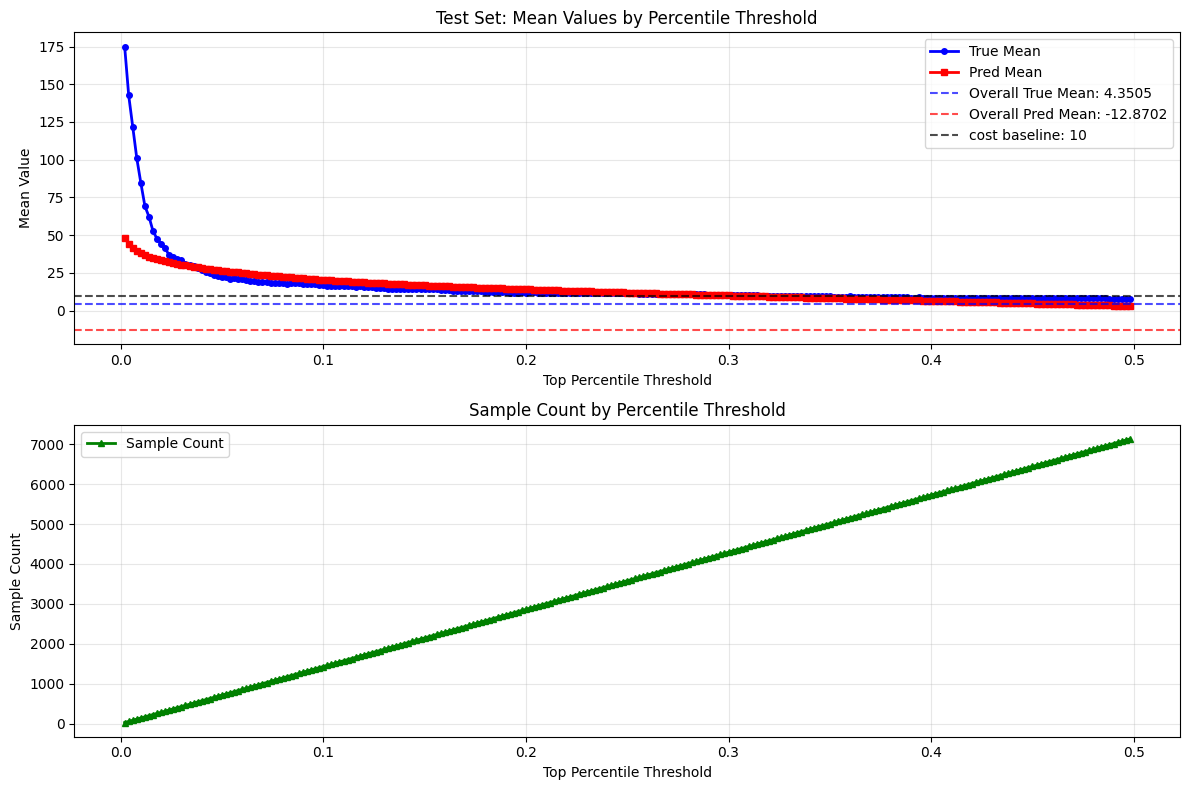

Test Set Evaluation:
  MAE: 43.7801, Relative MAE: 0.7852
  RMSE: 59.7292, Relative RMSE: 1.0713
  R²: -0.1477
  Overall True Mean: 4.3505
  Overall Pred Mean: -12.8702

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   174.9986    48.2441            29  -126.7545
1         0.004   142.5498    44.3872            58   -98.1626
2         0.006   121.6158    41.6484            86   -79.9674
3         0.008   100.8246    39.6472           115   -61.1775
4         0.010    84.4911    38.0394           144   -46.4517
..          ...        ...        ...           ...        ...
244       0.490     7.9742     3.3532          7015    -4.6211
245       0.492     7.9246     3.2843          7043    -4.6403
246       0.494     7.8890     3.2130          7072    -4.6760
247       0.496     7.8908     3.1417          7101    -4.7491
248       0.498     7.8873     3.0726          7129    -4.8147

[249 rows x 5 columns]


(2785, np.float64(11.90024717863733))

In [15]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [47]:
import numpy as np
import pandas as pd

# Check for infinity values in X_train
print("Checking for infinity values in X_train...")

# Method 1: Check which rows contain infinity values
inf_mask = np.isinf(X_train).any(axis=1)
invalid_rows = X_train[inf_mask]



Checking for infinity values in X_train...


In [48]:

def model_evaluation(y_true, y_pred, dataset_type="Train",thres = 5,if_plot=True, if_stats=True):
    from sklearn.metrics import mean_squared_error, r2_score
    import matplotlib.pyplot as plt
    
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    std = y_true.std()
    
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    relative_mae = mae / std if std != 0 else float('inf')
    relative_rmse = rmse / std if std != 0 else float('inf')
    
    # 存储每个百分位的结果
    percentiles = []
    true_means = []
    pred_means = []
    sample_counts = []
    
    for top_pct in np.arange(0.002, 0.5, 0.002):
        threshold = np.percentile(y_pred, (1-top_pct) * 100)  # 选择最大的top_pct比例
        mask = y_pred >= threshold
        filtered_y_true = y_true[mask]
        filtered_y_pred = y_pred[mask]
        
        if len(filtered_y_true) > 0:  # 确保有数据
            percentiles.append(top_pct)
            true_means.append(np.mean(filtered_y_true))
            pred_means.append(np.mean(filtered_y_pred))
            sample_counts.append(len(filtered_y_true))
    
    # 计算总体均值
    overall_true_mean = np.mean(y_true)
    overall_pred_mean = np.mean(y_pred)

    y_true_filtered = []
    for i in range(len(y_true)):
        if y_pred[i] >thres:
            y_true_filtered.append(y_true[i])
        

    
    # 绘制折线图
    if if_plot:
        plt.figure(figsize=(12, 8))
        
        # 主图：均值对比
        plt.subplot(2, 1, 1)
        plt.plot(percentiles, true_means, 'b-o', label=f'True Mean', linewidth=2, markersize=4)
        plt.plot(percentiles, pred_means, 'r-s', label=f'Pred Mean', linewidth=2, markersize=4)
        plt.axhline(y=overall_true_mean, color='blue', linestyle='--', alpha=0.7, 
                    label=f'Overall True Mean: {overall_true_mean:.4f}')
        plt.axhline(y=overall_pred_mean, color='red', linestyle='--', alpha=0.7,
                    label=f'Overall Pred Mean: {overall_pred_mean:.4f}')
        plt.axhline(y=10, color='black', linestyle='--', alpha=0.7,
                label=f'cost baseline: 10')
        
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Mean Value')
        plt.title(f'{dataset_type} Set: Mean Values by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 副图：样本数量
        plt.subplot(2, 1, 2)
        plt.plot(percentiles, sample_counts, 'g-^', label='Sample Count', linewidth=2, markersize=4)
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Sample Count')
        plt.title('Sample Count by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    if if_stats:
        # 输出基本评估指标
        print(f"{dataset_type} Set Evaluation:")
        print(f"  MAE: {mae:.4f}, Relative MAE: {relative_mae:.4f}")
        print(f"  RMSE: {rmse:.4f}, Relative RMSE: {relative_rmse:.4f}")
        print(f"  R²: {r2:.4f}")
        print(f"  Overall True Mean: {overall_true_mean:.4f}")
        print(f"  Overall Pred Mean: {overall_pred_mean:.4f}\n")
        
        # 输出百分位分析表
        percentile_df = pd.DataFrame({
            'Percentile': percentiles,
            'True_Mean': true_means,
            'Pred_Mean': pred_means,
            'Sample_Count': sample_counts,
            'Mean_Diff': np.array(pred_means) - np.array(true_means)
        })
        
        print(f"{dataset_type} Set Percentile Analysis:")
        print(percentile_df.round(4))
    return len(y_true_filtered), np.mean(y_true_filtered),

    # # return percentile_df

In [48]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge.fit(X_train_80, y_train_80)

val_pred = ridge.predict(X_train_20)
print("Ridge val MSE:", mean_squared_error(y_train_20, val_pred))


Ridge val MSE: 11188.707400144769


In [49]:

# ===============================
# 1. 随机划分 80% / 20%（模拟你原来的 90/10 early stop）
# ===============================
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[:split]
y_train_80 = y_train[:split]

X_train_20 = X_train.iloc[split:]
y_train_20 = y_train[split:]

# ===============================
# 2. 定义 LightGBM 回归模型
# ===============================
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mse",
    boosting_type="gbdt",

    n_estimators=8000,
    learning_rate=0.05,

    num_leaves=127,          # 🔥 放开表达能力
    max_depth=-1,

    min_data_in_leaf=30,     # 🔥 关键：从 200 → 30
    min_gain_to_split=0.0,

    subsample=1.0,           # 🔥 先别采样
    subsample_freq=0,
    colsample_bytree=1.0,

    reg_lambda=0.5,          # 轻度 L2，别太狠

    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# ===============================
# 3. 训练（Early Stopping）
# ===============================
print("Training LightGBM with early stopping...")

model.fit(
    X_train_80,
    y_train_80,
    eval_set=[(X_train_20, y_train_20)],
    eval_metric="mse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True)
    ]
)

# ===============================
# 4. 验证集评估
# ===============================
val_pred = model.predict(X_train_20, num_iteration=model.best_iteration_)
val_mse = mean_squared_error(y_train_20, val_pred)

print(f"Validation MSE: {val_mse:.6f}")
print(f"Best iteration: {model.best_iteration_}")

# ===============================
# 5. 全量预测
# ===============================
y_train_pred = model.predict(X_train, num_iteration=model.best_iteration_)
y_test_pred = model.predict(X_test, num_iteration=model.best_iteration_)

# ===============================
# 6. 可选：特征重要性
# ===============================
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)


Training LightGBM with early stopping...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 4267.45
Validation MSE: 4267.447864
Best iteration: 1


In [51]:
print(np.std(y_val), np.mean(y_val))


NameError: name 'y_val' is not defined

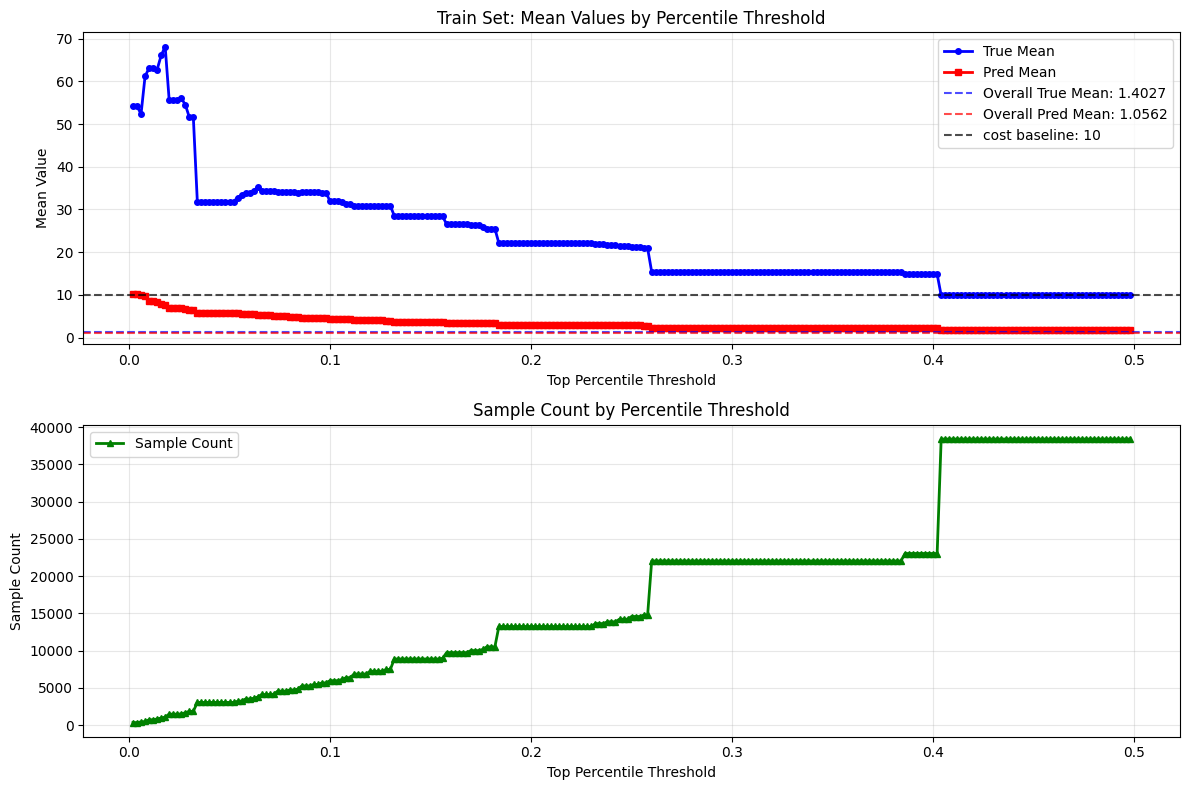

Train Set Evaluation:
  MAE: 35.8428, Relative MAE: 0.6830
  RMSE: 51.8195, Relative RMSE: 0.9874
  R²: 0.0250
  Overall True Mean: 1.4027
  Overall Pred Mean: 1.0562

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    54.1540    10.2796           333   -43.8744
1         0.004    54.1540    10.2796           333   -43.8744
2         0.006    52.3486    10.0103           415   -42.3383
3         0.008    61.1852     9.6733           474   -51.5119
4         0.010    63.0850     8.5886           711   -54.4964
..          ...        ...        ...           ...        ...
244       0.490     9.8668     1.7552         38394    -8.1116
245       0.492     9.8668     1.7552         38394    -8.1116
246       0.494     9.8668     1.7552         38394    -8.1116
247       0.496     9.8668     1.7552         38394    -8.1116
248       0.498     9.8668     1.7552         38394    -8.1116

[249 rows x 5 columns]


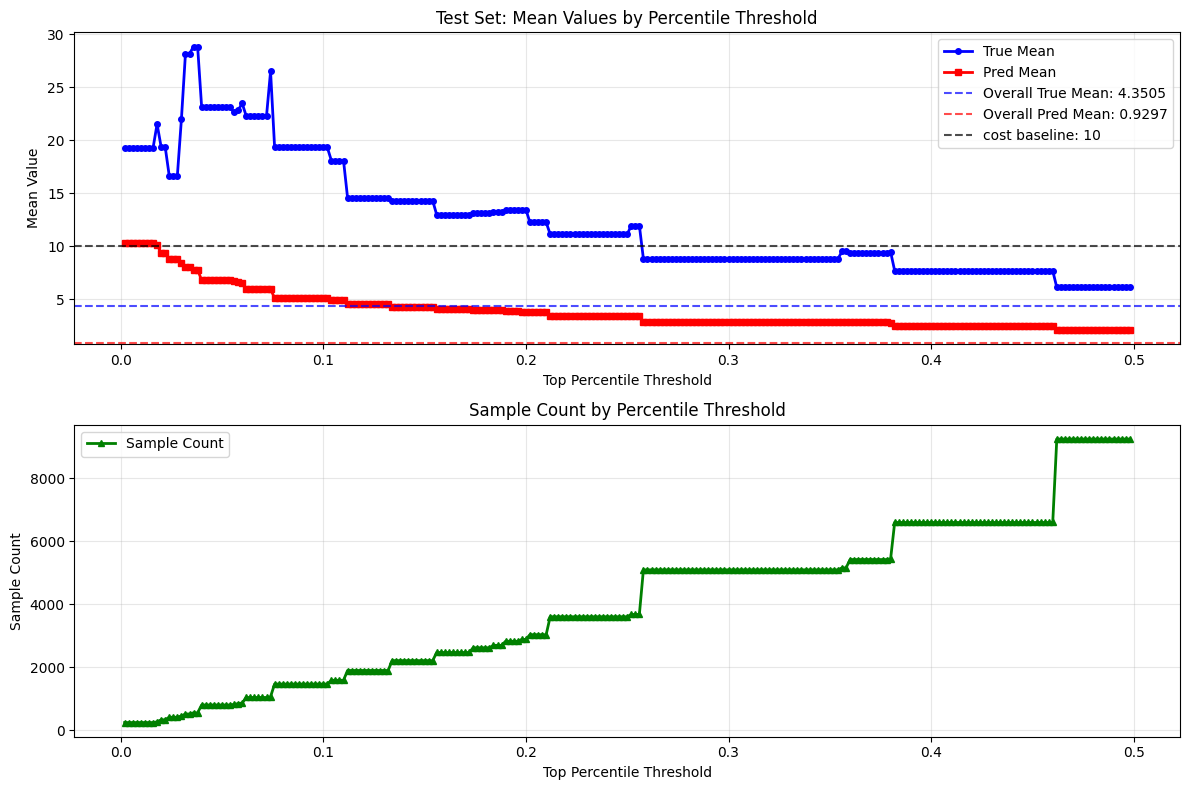

Test Set Evaluation:
  MAE: 38.6521, Relative MAE: 0.6932
  RMSE: 55.7513, Relative RMSE: 0.9999
  R²: 0.0001
  Overall True Mean: 4.3505
  Overall Pred Mean: 0.9297

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    19.2576    10.2796           239    -8.9780
1         0.004    19.2576    10.2796           239    -8.9780
2         0.006    19.2576    10.2796           239    -8.9780
3         0.008    19.2576    10.2796           239    -8.9780
4         0.010    19.2576    10.2796           239    -8.9780
..          ...        ...        ...           ...        ...
244       0.490     6.1251     2.1058          9245    -4.0193
245       0.492     6.1251     2.1058          9245    -4.0193
246       0.494     6.1251     2.1058          9245    -4.0193
247       0.496     6.1251     2.1058          9245    -4.0193
248       0.498     6.1251     2.1058          9245    -4.0193

[249 rows x 5 columns]


(512, np.float64(28.15674803568436))

In [52]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Random Forest 参数设置
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=500,
    min_samples_leaf=250,
    
    max_samples=0.8,
    max_features=0.8,
    
    n_jobs=-1,
    random_state=42
)

# 数据分割
random_index = np.random.permutation(len(X_train))
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[random_index[:split]]
y_train_80 = y_train[random_index[:split]]

X_train_20 = X_train.iloc[random_index[split:]]
y_train_20 = y_train[random_index[split:]]

# 训练模型
print("Training Random Forest...")
model.fit(X_train_80, y_train_80)

# 验证集评估
val_pred = model.predict(X_train_20)
val_mse = mean_squared_error(y_train_20, val_pred)
print(f"Validation MSE: {val_mse:.6f}")

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

print("Feature importance:")
for name, importance in zip(feature_names, feature_importance):
    print(f"  {name}: {importance:.4f}")
    

Training Random Forest...


KeyboardInterrupt: 

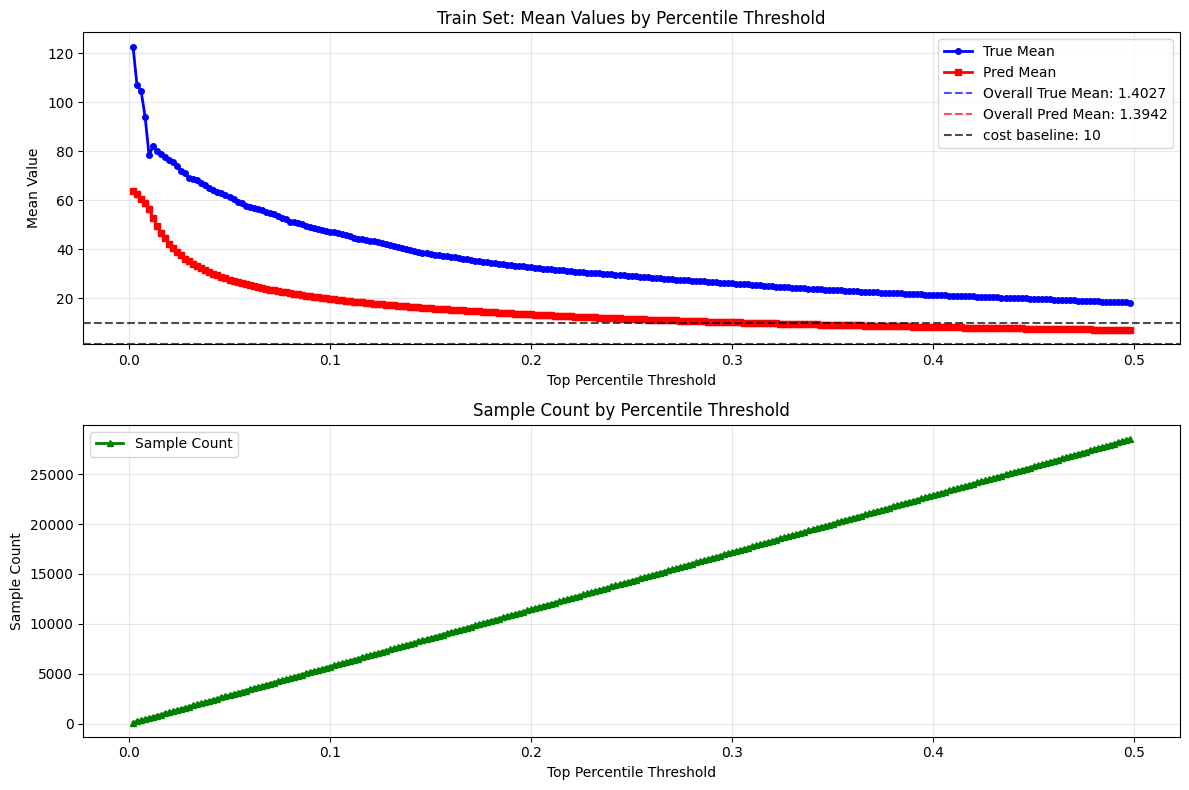

Train Set Evaluation:
  MAE: 33.9885, Relative MAE: 0.6476
  RMSE: 48.5886, Relative RMSE: 0.9258
  R²: 0.1428
  Overall True Mean: 1.4027
  Overall Pred Mean: 1.3942

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   122.8486    64.0141           115   -58.8345
1         0.004   106.9366    62.4038           230   -44.5329
2         0.006   104.7988    60.7194           344   -44.0795
3         0.008    94.2177    58.9845           459   -35.2332
4         0.010    78.3343    56.4000           573   -21.9343
..          ...        ...        ...           ...        ...
244       0.490    18.5034     7.1074         28059   -11.3960
245       0.492    18.4274     7.0847         28175   -11.3427
246       0.494    18.3598     7.0627         28288   -11.2971
247       0.496    18.2946     7.0405         28403   -11.2540
248       0.498    18.2578     7.0187         28517   -11.2392

[249 rows x 5 columns]


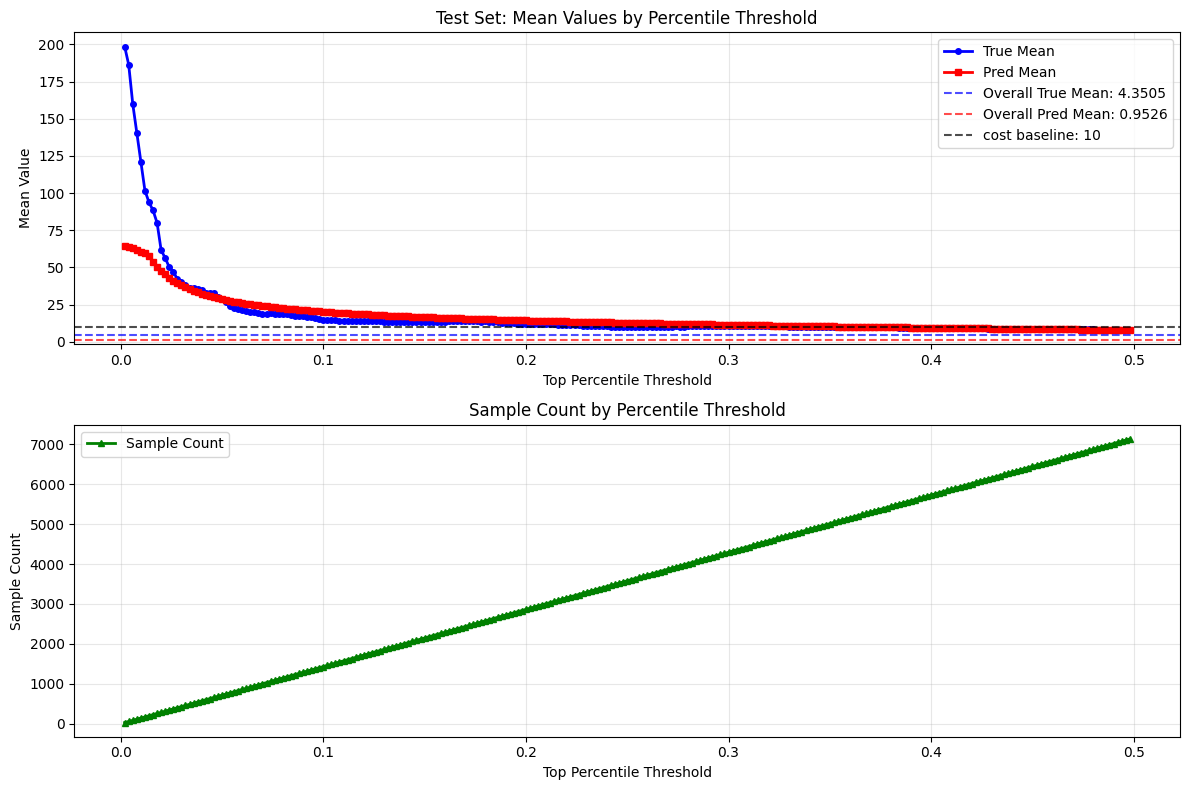

Test Set Evaluation:
  MAE: 38.5927, Relative MAE: 0.6922
  RMSE: 55.3867, Relative RMSE: 0.9934
  R²: 0.0131
  Overall True Mean: 4.3505
  Overall Pred Mean: 0.9526

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   198.6427    64.3630            31  -134.2797
1         0.004   186.3654    63.7133            58  -122.6521
2         0.006   159.9699    62.8850            86   -97.0849
3         0.008   140.6057    61.6744           115   -78.9313
4         0.010   121.0045    60.6315           144   -60.3731
..          ...        ...        ...           ...        ...
244       0.490     7.9961     7.9390          7015    -0.0570
245       0.492     7.9283     7.9121          7043    -0.0162
246       0.494     7.9189     7.8843          7072    -0.0346
247       0.496     7.8762     7.8567          7101    -0.0195
248       0.498     7.8072     7.8301          7129     0.0229

[249 rows x 5 columns]


(3820, np.float64(9.947630116902387))

In [55]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")